<a href="https://colab.research.google.com/github/Dalangans/CNN-PlantDisease/blob/main/Tugas_UAS_AI_Kelompok5_LOCAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning-Based Plant Disease Identification Using Convolutional Neural Networks

## Convolutional Neural Network (CNN)

### Proyek Pengganti UAS  
Mata Kuliah Kecerdasan Buatan  
Semester Genap 2025/2026  

---

## Disusun Oleh

| Nama | NPM |
|---|---|
| Nabiel Harits Utomo | 2306267044 |
| Muhammad Pavel | 2306242363 |
| R. Aisha Syauqi Ramadhani | 2306250554 |
| Zhafira Zahra Alfarisy | 2306250636 |

---

## Dosen Pengampu
Muhammad Firdaus Syawaludin Lubis, S.T., M.T., Ph.D.

# Deskripsi Proyek

Proyek ini bertujuan untuk membangun model klasifikasi penyakit daun tanaman menggunakan pendekatan *Deep Learning* berbasis *Convolutional Neural Network* (CNN).

Dataset yang digunakan berasal dari *PlantVillage Dataset* dengan fokus pada klasifikasi 5 jenis penyakit daun tomat.

Pada proyek ini dilakukan beberapa tahapan, meliputi:
- preprocessing data dan *data augmentation*,
- pelatihan *baseline CNN*,
- evaluasi performa model,
- implementasi *transfer learning* menggunakan *MobileNetV2*,
- serta proses *fine-tuning* untuk meningkatkan performa klasifikasi.

Model dievaluasi menggunakan beberapa metrik seperti *accuracy, precision, recall, F1-score,* dan *confusion matrix* untuk menganalisis performa klasifikasi secara lebih komprehensif.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, accuracy_score
)

plt.rcParams['figure.dpi']         = 120
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 2. DATA PREPARATION


In [ ]:
dataset_path = r"D:\COLLEGE\SEM 6\AI\plant_disease_dataset"

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Dataset Path :", dataset_path)
print("Folder ada   :", os.path.exists(dataset_path))

Dataset Path : D:\COLLEGE\SEM 6\AI\plant_disease_dataset
Folder ada   : True


### 2.2 Data Preprocessing

Tahapan preprocessing meliputi:

| Tahap | Konfigurasi |
|-------|-------------|
| Resize gambar | 224 × 224 piksel |
| Normalisasi piksel | rescale = 1/255 |
| Rotasi | rotation_range = 20° |
| Flip horizontal | horizontal_flip = True |
| Zoom | zoom_range = 0.2 |
| Split validasi | 20% dari total data |

In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_data = eval_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

CLASS_NAMES       = list(train_data.class_indices.keys())
CLASS_NAMES_SHORT = ['Early Blight', 'Late Blight', 'Leaf Mold', 'Septoria L.S.', 'Healthy']

Found 5780 images belonging to 5 classes.
Found 1443 images belonging to 5 classes.
Found 1443 images belonging to 5 classes.


### 2.3 Informasi Kelas Dataset

Berikut merupakan daftar kelas penyakit tanaman yang digunakan dalam proyek.

In [ ]:
print("Classes:")
print(train_data.class_indices)

Classes:
{'Tomato_Early_blight': 0, 'Tomato_Late_blight': 1, 'Tomato_Leaf_Mold': 2, 'Tomato_Septoria_leaf_spot': 3, 'Tomato_healthy': 4}


### 2.4 Visualisasi Sampel Dataset

Berikut beberapa contoh citra daun tanaman dari dataset.

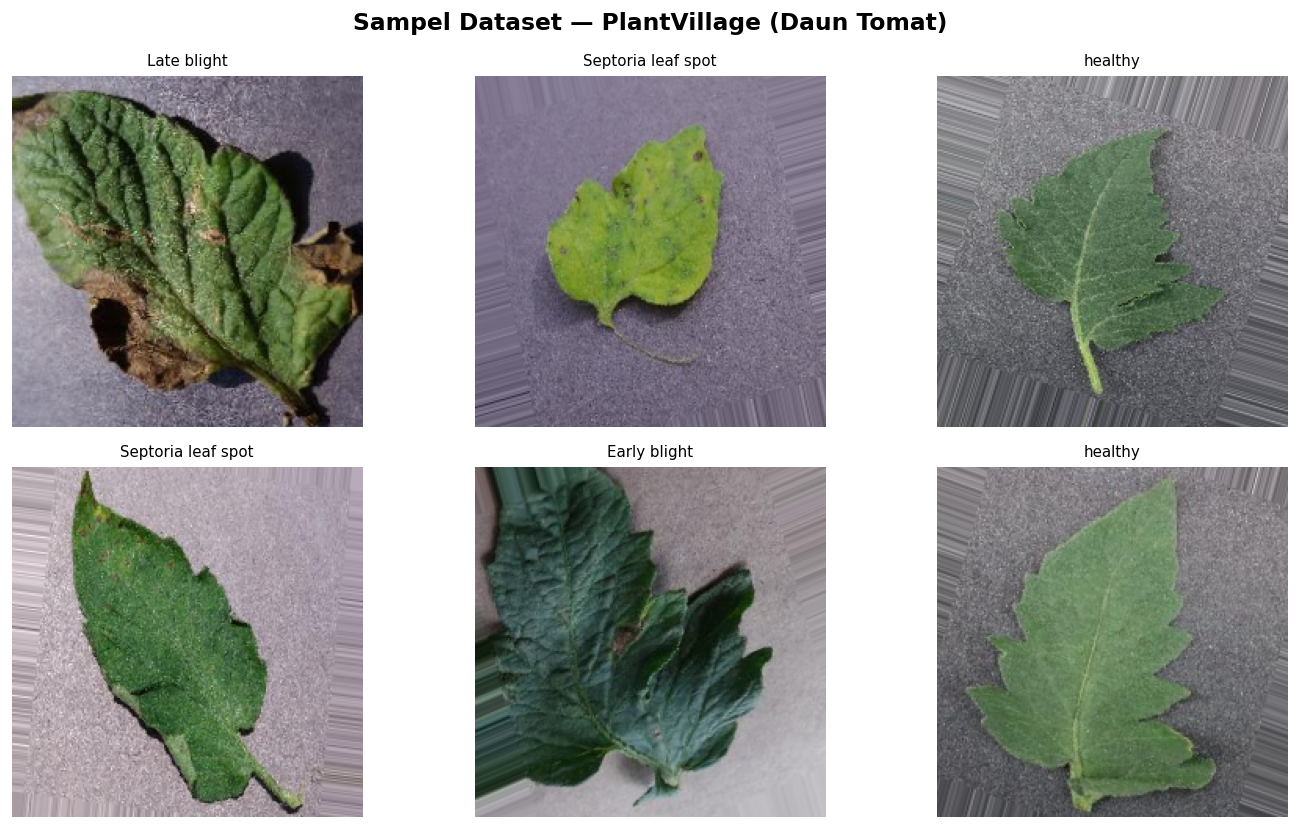

In [ ]:
images, labels = next(train_data)
label_map = {v: k for k, v in train_data.class_indices.items()}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('Sampel Dataset — PlantVillage (Daun Tomat)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    cls_idx = np.argmax(labels[i])
    ax.set_title(label_map[cls_idx].replace('Tomato_','').replace('_',' '), fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. BASELINE CNN
### 3.1 Arsitektur Baseline CNN

Model baseline CNN menggunakan arsitektur **3 blok konvolusi** sebagai referensi awal:

```
Input (224×224×3)
  → Conv2D(32) + ReLU → MaxPooling
  → Conv2D(64) + ReLU → MaxPooling
  → Conv2D(128) + ReLU → MaxPooling
  → Flatten
  → Dense(128) + ReLU
  → Dropout(0.5)
  → Dense(5, Softmax)
```

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Compile Model

| Komponen | Konfigurasi |
|----------|-------------|
| Optimizer | Adam (default lr=1e-3) |
| Loss | Categorical Crossentropy |
| Metrik | Accuracy |

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 3.3 Training Baseline CNN

Proses training dilakukan selama **10 epoch** menggunakan dataset training dan validation.

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 132s 718ms/step - accuracy: 0.5500 - loss: 1.1291 - val_accuracy: 0.6355 - val_loss: 0.8759
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 131s 725ms/step - accuracy: 0.7524 - loss: 0.6648 - val_accuracy: 0.7983 - val_loss: 0.5574
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 135s 746ms/step - accuracy: 0.8234 - loss: 0.4995 - val_accuracy: 0.8565 - val_loss: 0.3804
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 122s 671ms/step - accuracy: 0.8206 - loss: 0.4794 - val_accuracy: 0.8538 - val_loss: 0.3868
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 122s 676ms/step - accuracy: 0.8588 - loss: 0.3848 - val_accuracy: 0.8635 - val_loss: 0.3182
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 121s 670ms/step - accuracy: 0.8642 - loss: 0.3748 - val_accuracy: 0.8981 - val_loss: 0.2502
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 120s 663ms/step - accuracy: 0.8872 - loss: 0.3133 - val_accuracy: 0.8857 - val_loss: 0.3026
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 137s 759ms/step - accuracy: 0.8785 -

### 3.4 Grafik Accuracy & Loss

Grafik berikut menunjukkan perkembangan **accuracy** dan **loss** selama proses training.

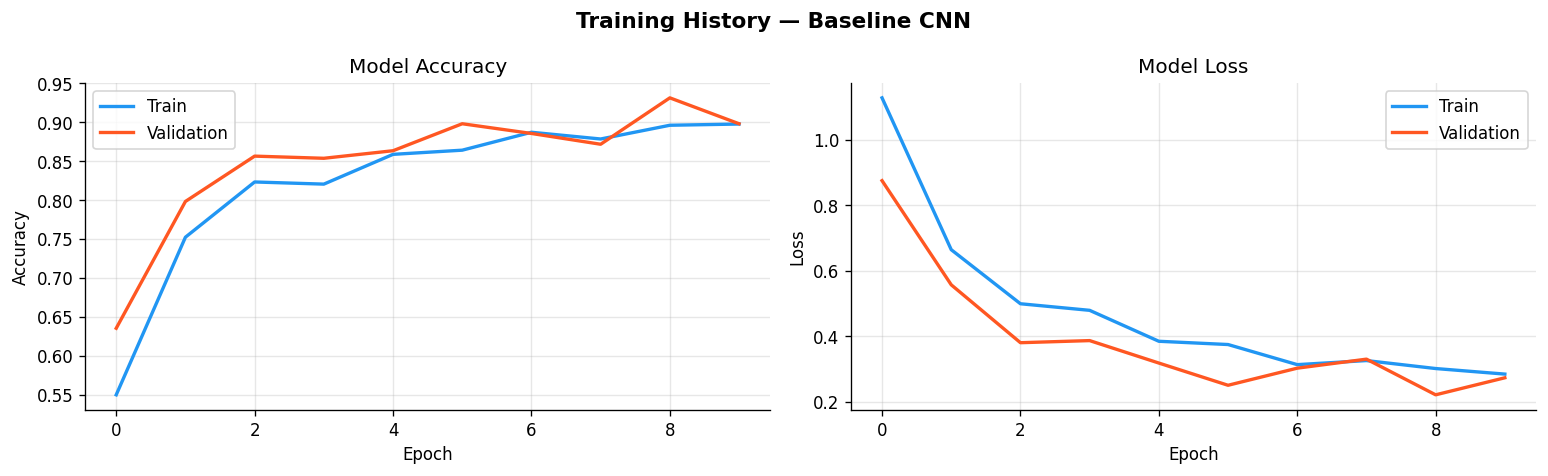

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History — Baseline CNN', fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train',      color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#FF5722', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train',      color='#2196F3', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#FF5722', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Evaluasi Awal — Validation Loss & Accuracy

In [ ]:
loss, accuracy = model.evaluate(val_data)
print("Validation Loss    :", loss)
print("Validation Accuracy:", accuracy)

46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.8981 - loss: 0.2674
Validation Loss    : 0.26738372445106506
Validation Accuracy: 0.8981289267539978


### 3.6 Simpan Model Baseline

In [ ]:
model.save("models/baseline_cnn.keras")
print("Model baseline berhasil disimpan ke models/baseline_cnn.keras")

Model baseline berhasil disimpan ke models/baseline_cnn.keras


## 4. EVALUASI & METRIK

Evaluasi komprehensif baseline CNN menggunakan:
- **Confusion Matrix** — visualisasi kesalahan klasifikasi antar kelas
- **Classification Report** — precision, recall, F1-score per kelas
- **Grafik metrik** — perbandingan visual antar kelas

### 4.1 Prediksi pada Data Validasi

In [ ]:
# Reset generator sebelum prediksi
eval_data.reset()

y_pred_proba = model.predict(eval_data, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = eval_data.classes

print(f"Total sampel validasi: {len(y_true)}")
print(f"Distribusi label     : {dict(zip(*np.unique(y_true, return_counts=True)))}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step
Total sampel validasi: 1443
Distribusi label     : {np.int32(0): np.int64(200), np.int32(1): np.int64(381), np.int32(2): np.int64(190), np.int32(3): np.int64(354), np.int32(4): np.int64(318)}


### 4.2 Confusion Matrix

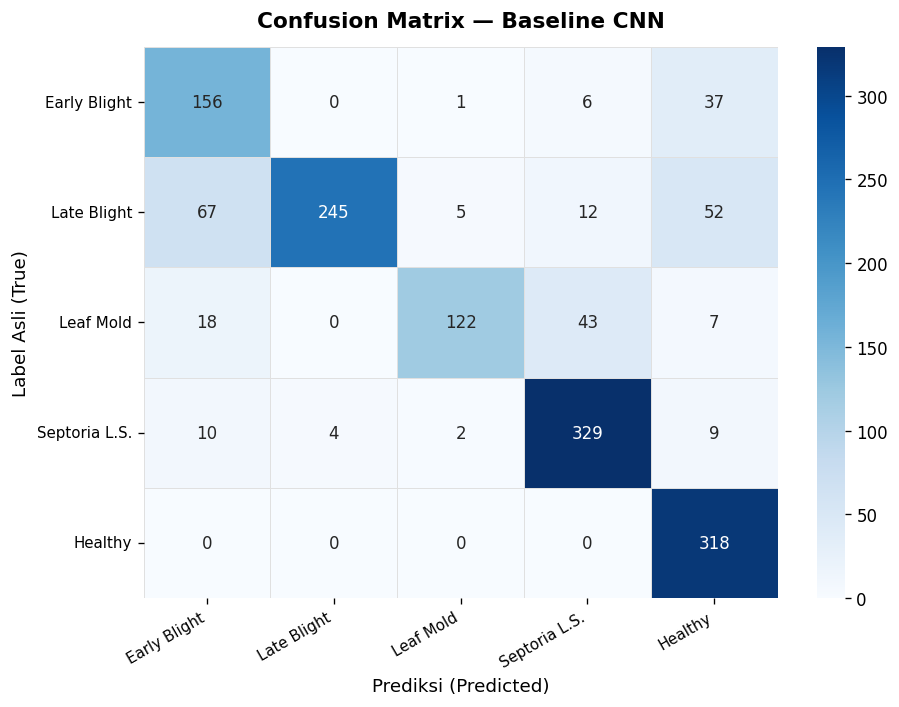

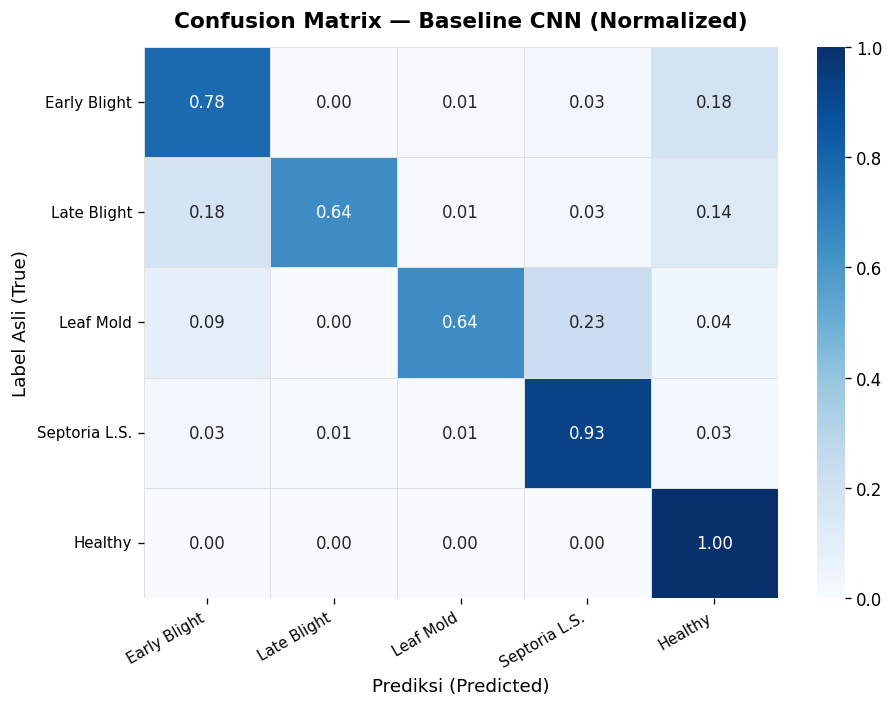

array([[156,   0,   1,   6,  37],
       [ 67, 245,   5,  12,  52],
       [ 18,   0, 122,  43,   7],
       [ 10,   4,   2, 329,   9],
       [  0,   0,   0,   0, 318]])

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix', normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt, title = '.2f', title + ' (Normalized)'
    else:
        cm_plot, fmt = cm, 'd'

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.4, linecolor='#e0e0e0')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Label Asli (True)', fontsize=11)
    ax.set_xlabel('Prediksi (Predicted)', fontsize=11)
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()
    return cm

cm_baseline = plot_confusion_matrix(y_true, y_pred, CLASS_NAMES_SHORT,
                                     title='Confusion Matrix — Baseline CNN')
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES_SHORT,
                       title='Confusion Matrix — Baseline CNN', normalize=True)

### 4.3 Classification Report

In [ ]:
print("Classification Report — Baseline CNN")
print("=" * 62)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_SHORT, digits=4))

acc  = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
f1_m = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy          : {acc:.4f}")
print(f"Weighted F1-Score : {f1_w:.4f}")
print(f"Macro F1-Score    : {f1_m:.4f}")

Classification Report — Baseline CNN
               precision    recall  f1-score   support

 Early Blight     0.6215    0.7800    0.6918       200
  Late Blight     0.9839    0.6430    0.7778       381
    Leaf Mold     0.9385    0.6421    0.7625       190
Septoria L.S.     0.8436    0.9294    0.8844       354
      Healthy     0.7518    1.0000    0.8583       318

     accuracy                         0.8108      1443
    macro avg     0.8279    0.7989    0.7950      1443
 weighted avg     0.8421    0.8108    0.8078      1443

Accuracy          : 0.8108
Weighted F1-Score : 0.8078
Macro F1-Score    : 0.7950


### 4.4 Visualisasi F1-Score per Kelas

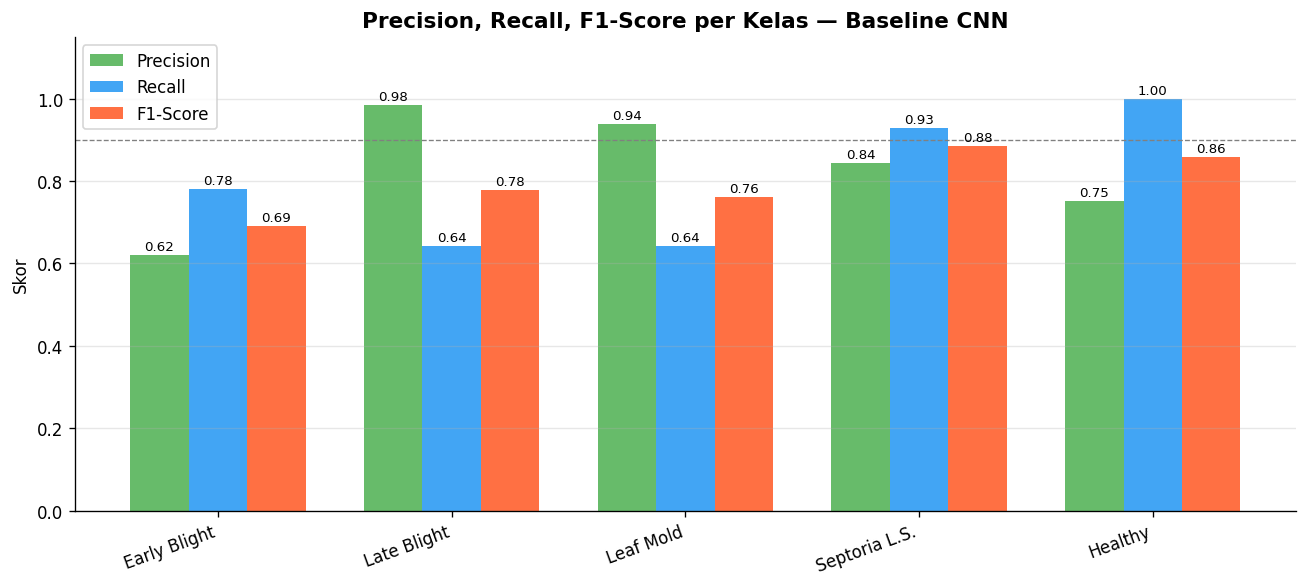

        Kelas  Precision   Recall  F1-Score
 Early Blight   0.621514 0.780000  0.691796
  Late Blight   0.983936 0.643045  0.777778
    Leaf Mold   0.938462 0.642105  0.762500
Septoria L.S.   0.843590 0.929379  0.884409
      Healthy   0.751773 1.000000  0.858300


In [ ]:
report_dict = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES_SHORT, output_dict=True
)

metrics_df = pd.DataFrame({
    'Kelas'    : CLASS_NAMES_SHORT,
    'Precision': [report_dict[c]['precision'] for c in CLASS_NAMES_SHORT],
    'Recall'   : [report_dict[c]['recall']    for c in CLASS_NAMES_SHORT],
    'F1-Score' : [report_dict[c]['f1-score']  for c in CLASS_NAMES_SHORT],
})

x, w = np.arange(len(CLASS_NAMES_SHORT)), 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for offset, col, color in zip([-w, 0, w],
                               ['Precision', 'Recall', 'F1-Score'],
                               ['#4CAF50', '#2196F3', '#FF5722']):
    bars = ax.bar(x + offset, metrics_df[col], w, label=col, color=color, alpha=0.85)
    for b in bars:
        ax.annotate(f'{b.get_height():.2f}',
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES_SHORT, rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Precision, Recall, F1-Score per Kelas — Baseline CNN', fontsize=13, fontweight='bold')
ax.set_ylabel('Skor')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(metrics_df.to_string(index=False))

## 5. TRANSFER LEARNING — MobileNetV2

Transfer learning menggunakan **MobileNetV2** pretrained ImageNet dalam **2 fase**:

| Fase | Deskripsi | Learning Rate |
|------|-----------|---------------|
| Fase 1 — Feature Extraction | Semua layer base di-*freeze* | 1e-4 |
| Fase 2 — Fine-tuning | 30 layer terakhir di-*unfreeze* | 1e-5 |

### 5.1 Membangun Model MobileNetV2 (Fase 1 — Feature Extraction)

In [ ]:
def build_mobilenetv2(num_classes, dropout_rate=0.5, learning_rate=1e-4):
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_mobile = tf.keras.Model(inputs, outputs)
    model_mobile.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model_mobile, base_model

mobilenet_model, base_model = build_mobilenetv2(num_classes=len(CLASS_NAMES))
mobilenet_model.summary()
print(f"\nLayer base yang difreeze: {len([l for l in base_model.layers if not l.trainable])}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Layer base yang difreeze: 154


### 5.2 Callbacks Training

In [ ]:
callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        'models/mobilenetv2_phase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]
print("Callbacks siap ✓")

Callbacks siap ✓


### 5.3 Training Fase 1 — Feature Extraction

In [ ]:
print("FASE 1 — Feature Extraction (base model frozen)")
print("=" * 50)

history_p1 = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks_p1,
    verbose=1
)

print(f"\nVal accuracy terbaik (Fase 1): {max(history_p1.history['val_accuracy']):.4f}")

FASE 1 — Feature Extraction (base model frozen)
Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.3874 - loss: 1.5720
Epoch 1: val_accuracy improved from None to 0.76992, saving model to models/mobilenetv2_phase1_best.keras

Epoch 1: finished saving model to models/mobilenetv2_phase1_best.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 125s 666ms/step - accuracy: 0.5299 - loss: 1.2359 - val_accuracy: 0.7699 - val_loss: 0.7125 - learning_rate: 1.0000e-04
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.7048 - loss: 0.8015
Epoch 2: val_accuracy improved from 0.76992 to 0.81358, saving model to models/mobilenetv2_phase1_best.keras

Epoch 2: finished saving model to models/mobilenetv2_phase1_best.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 117s 649ms/step - accuracy: 0.7292 - loss: 0.7367 - val_accuracy: 0.8136 - val_loss: 0.5345 - learning_rate: 1.0000e-04
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.7589 - loss: 0.6481
Epoch 3: val_accuracy improved 

### 5.4 Training Fase 2 — Fine-tuning

In [ ]:
print("FASE 2 — Fine-tuning (unfreeze 30 layer terakhir)")
print("=" * 50)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Layer trainable: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(
        'models/mobilenetv2_finetuned_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

history_p2 = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks_p2,
    verbose=1
)

print(f"\nVal accuracy terbaik (Fase 2): {max(history_p2.history['val_accuracy']):.4f}")

FASE 2 — Fine-tuning (unfreeze 30 layer terakhir)
Layer trainable: 30 / 154
Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6717 - loss: 0.9960
Epoch 1: val_accuracy improved from None to 0.86902, saving model to models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to models/mobilenetv2_finetuned_best.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 143s 752ms/step - accuracy: 0.7493 - loss: 0.7231 - val_accuracy: 0.8690 - val_loss: 0.3508 - learning_rate: 1.0000e-05
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8457 - loss: 0.4291
Epoch 2: val_accuracy improved from 0.86902 to 0.87665, saving model to models/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to models/mobilenetv2_finetuned_best.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 133s 735ms/step - accuracy: 0.8542 - loss: 0.4066 - val_accuracy: 0.8766 - val_loss: 0.3271 - learning_rate: 1.0000e-05
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8654 - loss

### 5.5 Grafik Training MobileNetV2

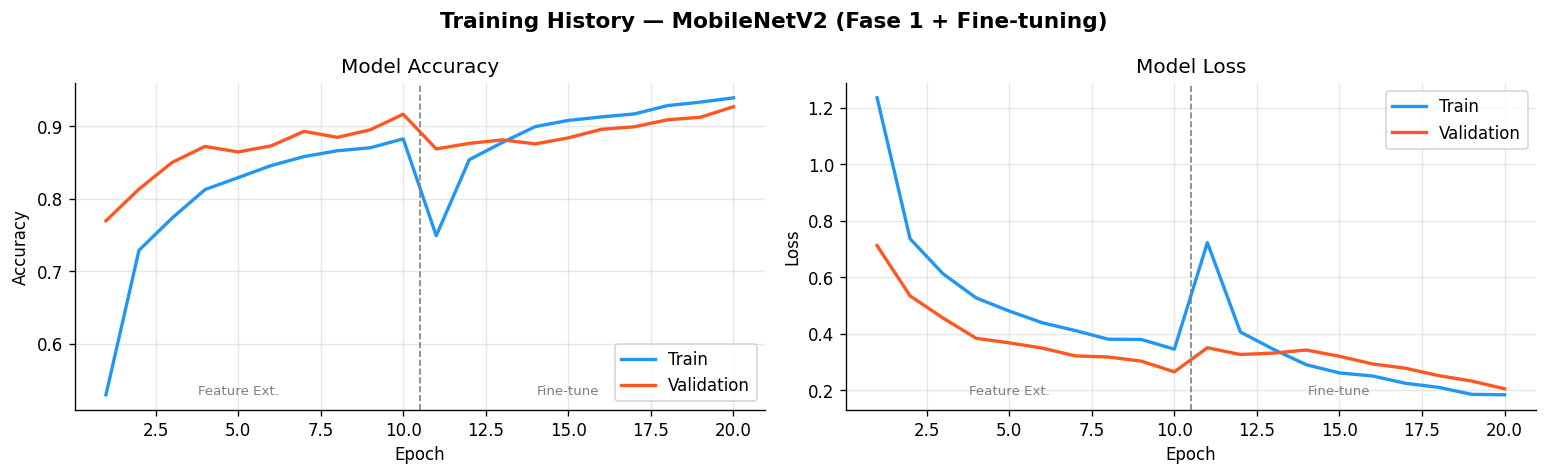

In [ ]:
n_p1 = len(history_p1.history['accuracy'])
combined = {k: history_p1.history[k] + history_p2.history[k]
            for k in history_p1.history}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History — MobileNetV2 (Fase 1 + Fine-tuning)', fontsize=13, fontweight='bold')

for ax, (train_k, val_k), title in zip(
    axes,
    [('accuracy','val_accuracy'), ('loss','val_loss')],
    ['Accuracy', 'Loss']
):
    ep = range(1, len(combined[train_k]) + 1)
    ax.plot(ep, combined[train_k], label='Train',      color='#2196F3', linewidth=2)
    ax.plot(ep, combined[val_k],   label='Validation', color='#FF5722', linewidth=2)
    ax.axvline(n_p1 + 0.5, color='gray', linestyle='--', linewidth=1)
    ymin = min(combined[train_k] + combined[val_k])
    ax.text(n_p1*0.5, ymin, 'Feature Ext.', ha='center', fontsize=8, color='gray')
    ax.text(n_p1 + len(history_p2.history['accuracy'])*0.5, ymin, 'Fine-tune', ha='center', fontsize=8, color='gray')
    ax.set_title(f'Model {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Evaluasi MobileNetV2

46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 413ms/step
Classification Report — MobileNetV2 Fine-tuned
               precision    recall  f1-score   support

 Early Blight     0.9384    0.6850    0.7919       200
  Late Blight     0.9538    0.9213    0.9372       381
    Leaf Mold     0.8139    0.9895    0.8931       190
Septoria L.S.     0.9158    0.9520    0.9335       354
      Healthy     0.9636    1.0000    0.9815       318

     accuracy                         0.9224      1443
    macro avg     0.9171    0.9095    0.9075      1443
 weighted avg     0.9261    0.9224    0.9201      1443



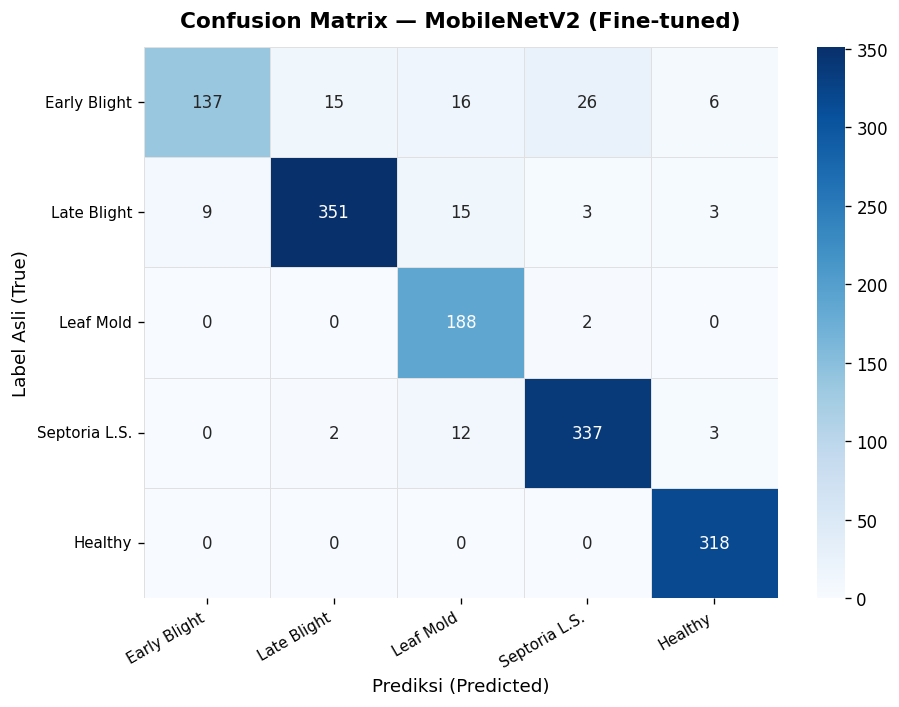

Model MobileNetV2 berhasil disimpan ke models/mobilenetv2_final.keras


In [ ]:
eval_data.reset()
y_pred_m_proba = mobilenet_model.predict(eval_data, verbose=1)
y_pred_m       = np.argmax(y_pred_m_proba, axis=1)

print("Classification Report — MobileNetV2 Fine-tuned")
print("=" * 62)
print(classification_report(y_true, y_pred_m, target_names=CLASS_NAMES_SHORT, digits=4))

cm_mobile = plot_confusion_matrix(y_true, y_pred_m, CLASS_NAMES_SHORT,
                                   title='Confusion Matrix — MobileNetV2 (Fine-tuned)')

mobilenet_model.save('models/mobilenetv2_final.keras')
print("Model MobileNetV2 berhasil disimpan ke models/mobilenetv2_final.keras")

## 6. ERROR ANALYSIS

Analisis mendalam terhadap sampel yang **salah diklasifikasikan** oleh model terbaik (MobileNetV2).

### 6.1 Identifikasi Sampel Salah Klasifikasi

In [ ]:
wrong_idx   = np.where(y_pred_m != y_true)[0]
correct_idx = np.where(y_pred_m == y_true)[0]

print(f"Total sampel validasi : {len(y_true)}")
print(f"Prediksi BENAR        : {len(correct_idx)}  ({len(correct_idx)/len(y_true)*100:.2f}%)")
print(f"Prediksi SALAH        : {len(wrong_idx)}  ({len(wrong_idx)/len(y_true)*100:.2f}%)")
print()

error_pairs = {}
for idx in wrong_idx:
    pair = f"{CLASS_NAMES_SHORT[y_true[idx]]} → {CLASS_NAMES_SHORT[y_pred_m[idx]]}"
    error_pairs[pair] = error_pairs.get(pair, 0) + 1

error_df = pd.DataFrame(
    sorted(error_pairs.items(), key=lambda x: x[1], reverse=True),
    columns=['Pasangan (True → Pred)', 'Jumlah']
)
print("Top pasangan kelas yang tertukar:")
print(error_df.to_string(index=False))

Total sampel validasi : 1443
Prediksi BENAR        : 1331  (92.24%)
Prediksi SALAH        : 112  (7.76%)

Top pasangan kelas yang tertukar:
      Pasangan (True → Pred)  Jumlah
Early Blight → Septoria L.S.      26
    Early Blight → Leaf Mold      16
  Early Blight → Late Blight      15
     Late Blight → Leaf Mold      15
   Septoria L.S. → Leaf Mold      12
  Late Blight → Early Blight       9
      Early Blight → Healthy       6
       Late Blight → Healthy       3
 Late Blight → Septoria L.S.       3
     Septoria L.S. → Healthy       3
   Leaf Mold → Septoria L.S.       2
 Septoria L.S. → Late Blight       2


### 6.2 Error Rate per Kelas

        Kelas  Total  Salah  Error Rate (%)
 Early Blight    200     63           31.50
  Late Blight    381     30            7.87
Septoria L.S.    354     17            4.80
    Leaf Mold    190      2            1.05
      Healthy    318      0            0.00


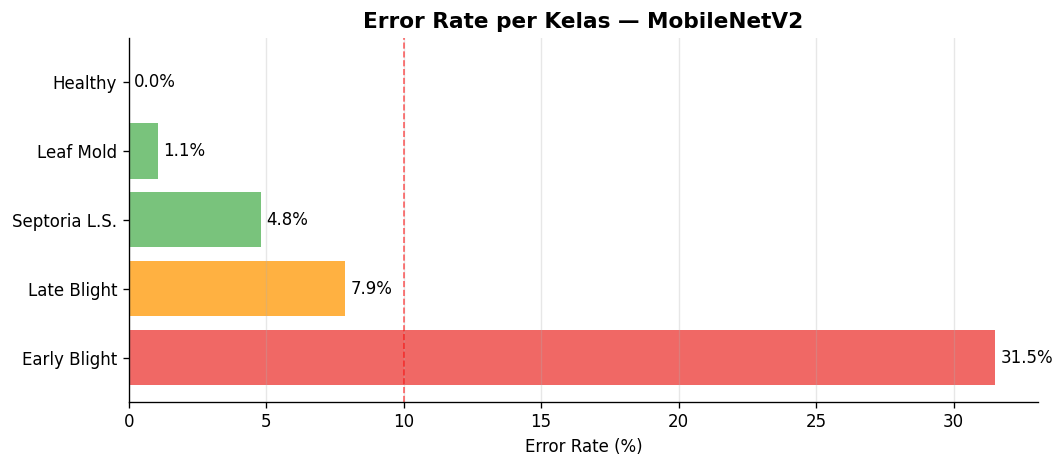

In [ ]:
err_rows = []
for i, cls in enumerate(CLASS_NAMES_SHORT):
    cls_idx   = np.where(y_true == i)[0]
    cls_wrong = np.where((y_true == i) & (y_pred_m != i))[0]
    rate = len(cls_wrong) / len(cls_idx) * 100 if len(cls_idx) else 0
    err_rows.append({'Kelas': cls, 'Total': len(cls_idx),
                     'Salah': len(cls_wrong), 'Error Rate (%)': round(rate, 2)})

err_rate_df = pd.DataFrame(err_rows).sort_values('Error Rate (%)', ascending=False)
print(err_rate_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#EF5350' if v > 10 else '#FFA726' if v > 5 else '#66BB6A'
          for v in err_rate_df['Error Rate (%)']]
bars = ax.barh(err_rate_df['Kelas'], err_rate_df['Error Rate (%)'],
               color=colors, alpha=0.88)
ax.axvline(10, color='red', linestyle='--', linewidth=1, alpha=0.6)
for b in bars:
    ax.text(b.get_width() + 0.2, b.get_y() + b.get_height()/2,
            f'{b.get_width():.1f}%', va='center', fontsize=10)
ax.set_xlabel('Error Rate (%)')
ax.set_title('Error Rate per Kelas — MobileNetV2', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Visualisasi Sampel Salah Prediksi


46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step
Jumlah salah prediksi: 112


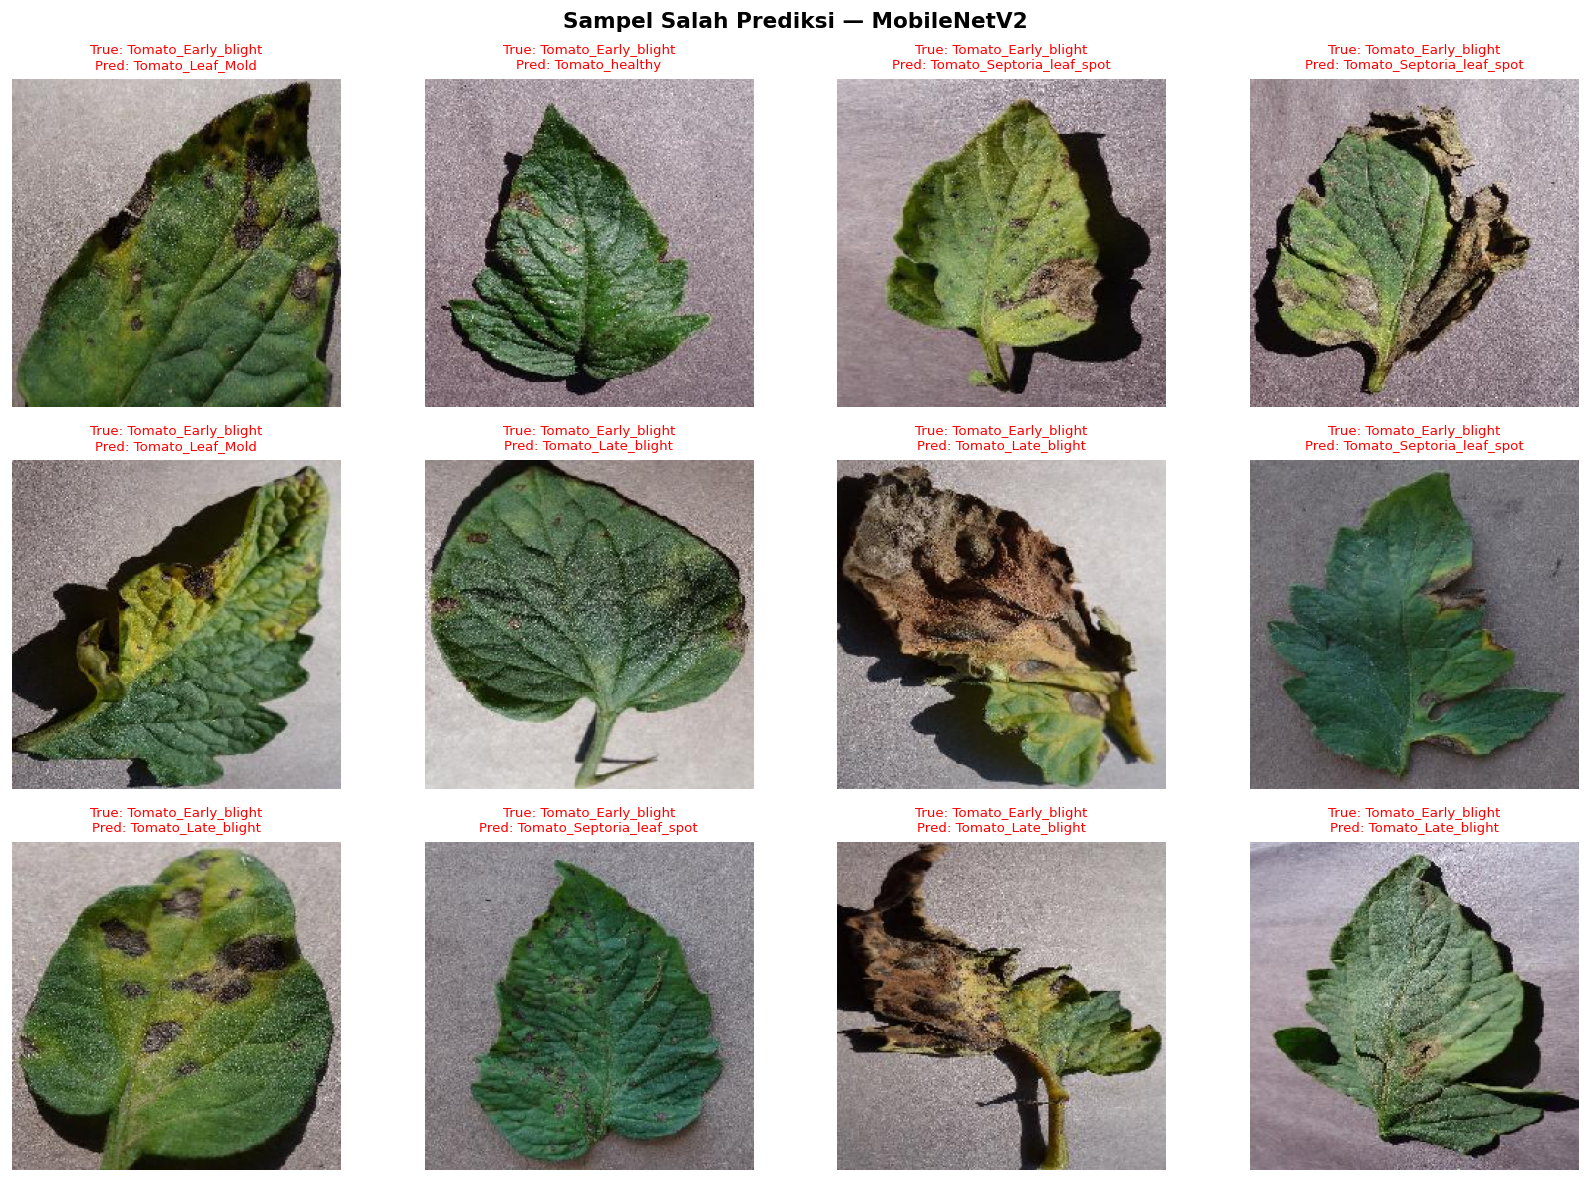

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

eval_data.reset()
all_imgs   = []
all_labels = []

for batch_x, batch_y in eval_data:
    all_imgs.append(batch_x)
    all_labels.append(batch_y)
    if len(all_imgs) * batch_x.shape[0] >= eval_data.n:
        break

all_imgs   = np.vstack(all_imgs)[:eval_data.n]
all_labels = np.vstack(all_labels)[:eval_data.n]

eval_data.reset()
pred_probs  = mobilenet_model.predict(eval_data, verbose=1)

pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(all_labels, axis=1)


wrong_idx = np.where(pred_labels != true_labels)[0]
print(f"Jumlah salah prediksi: {len(wrong_idx)}")


n_show     = min(12, len(wrong_idx))
class_names = list(eval_data.class_indices.keys())

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(n_show):
    idx = wrong_idx[i]
    axes[i].imshow(all_imgs[idx])
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}",
        fontsize=8, color="red"
    )

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sampel Salah Prediksi — MobileNetV2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.4 Analisis Confidence Score

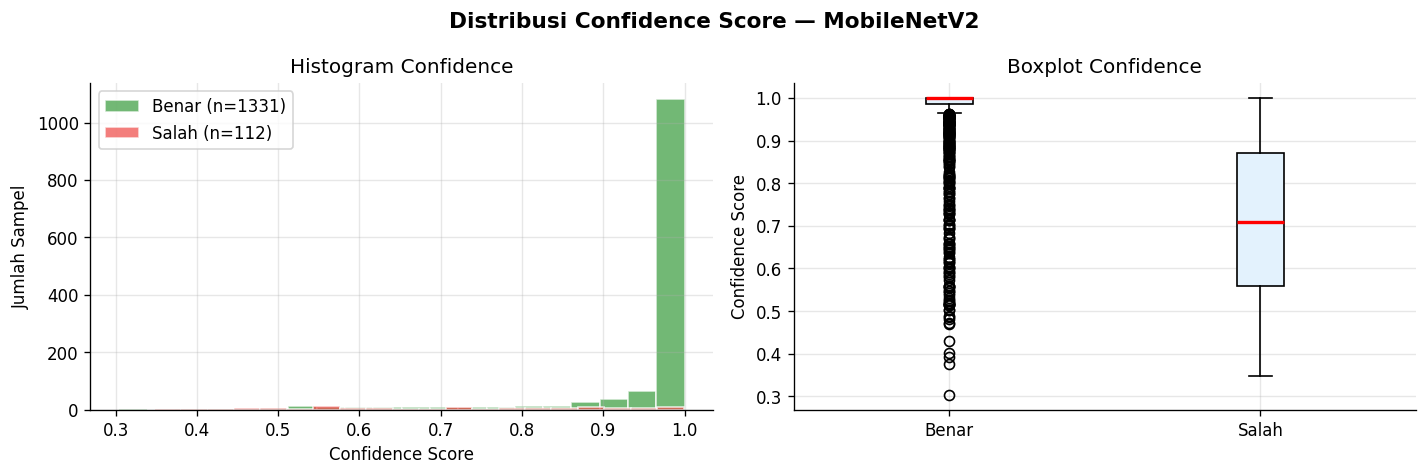

Confidence rata-rata (BENAR): 0.9601
Confidence rata-rata (SALAH): 0.7090
High-confidence errors (>80%): 41 sampel


In [ ]:
conf_all     = np.max(y_pred_m_proba, axis=1)
conf_correct = conf_all[correct_idx]
conf_wrong   = conf_all[wrong_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Confidence Score — MobileNetV2', fontsize=13, fontweight='bold')

axes[0].hist(conf_correct, bins=20, alpha=0.75, color='#43A047',
             label=f'Benar (n={len(conf_correct)})', edgecolor='white')
axes[0].hist(conf_wrong,   bins=20, alpha=0.75, color='#EF5350',
             label=f'Salah (n={len(conf_wrong)})',   edgecolor='white')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_title('Histogram Confidence')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot([conf_correct, conf_wrong], labels=['Benar', 'Salah'],
                patch_artist=True, boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Confidence Score')
axes[1].set_title('Boxplot Confidence')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Confidence rata-rata (BENAR): {conf_correct.mean():.4f}")
print(f"Confidence rata-rata (SALAH): {conf_wrong.mean():.4f}")
print(f"High-confidence errors (>80%): {(conf_wrong > 0.8).sum()} sampel")

## 7. PERBANDINGAN MODEL — Baseline CNN vs MobileNetV2

Perbandingan komprehensif kedua model sebagai bagian dari **Bonus B1**.

In [ ]:
acc_m   = accuracy_score(y_true, y_pred_m)
f1w_m   = f1_score(y_true, y_pred_m, average='weighted')
f1mac_m = f1_score(y_true, y_pred_m, average='macro')
prec_m  = precision_score(y_true, y_pred_m, average='weighted')
rec_m   = recall_score(y_true, y_pred_m, average='weighted')

acc    = accuracy_score(y_true, y_pred)
f1_w   = f1_score(y_true, y_pred, average='weighted')
f1_m   = f1_score(y_true, y_pred, average='macro')
prec_b = precision_score(y_true, y_pred, average='weighted')
rec_b  = recall_score(y_true, y_pred, average='weighted')

cmp = pd.DataFrame({
    'Metrik'                : ['Accuracy', 'Weighted F1', 'Macro F1', 'Precision', 'Recall'],
    'Baseline CNN'          : [acc,   f1_w,  f1_m,    prec_b, rec_b],
    'MobileNetV2 Fine-tune' : [acc_m, f1w_m, f1mac_m, prec_m, rec_m],
})

cmp['Delta (↑)'] = cmp['MobileNetV2 Fine-tune'] - cmp['Baseline CNN']

for col in ['Baseline CNN', 'MobileNetV2 Fine-tune', 'Delta (↑)']:
    cmp[col] = cmp[col].map(lambda x: f'{x:+.4f}' if col == 'Delta (↑)' else f'{x:.4f}')

print("=" * 65)
print("  PERBANDINGAN BASELINE CNN vs MobileNetV2")
print("=" * 65)
print(cmp.to_string(index=False))
print("=" * 65)

  PERBANDINGAN BASELINE CNN vs MobileNetV2
     Metrik Baseline CNN MobileNetV2 Fine-tune Delta (↑)
   Accuracy       0.8108                0.9224   +0.1116
Weighted F1       0.8078                0.9201   +0.1124
   Macro F1       0.7950                0.9075   +0.1125
  Precision       0.8421                0.9261   +0.0839
     Recall       0.8108                0.9224   +0.1116


### Bar Chart Perbandingan

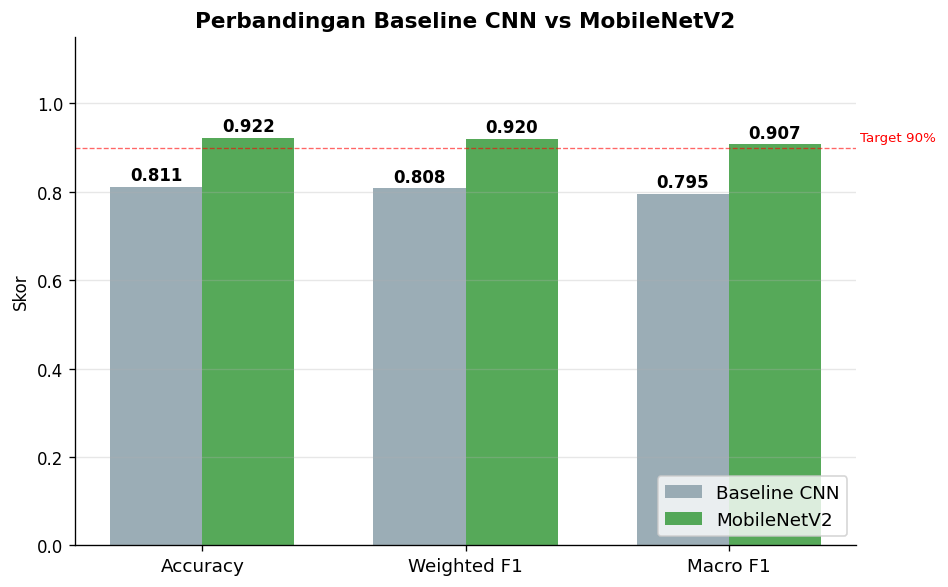

Chart disimpan ke results/comparison_baseline_vs_mobilenet.png


In [ ]:
acc  = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
f1_m = f1_score(y_true, y_pred, average='macro')

acc_m   = accuracy_score(y_true, y_pred_m)
f1w_m   = f1_score(y_true, y_pred_m, average='weighted')
f1mac_m = f1_score(y_true, y_pred_m, average='macro')

labels_cmp = ['Accuracy', 'Weighted F1', 'Macro F1']
vals_base  = [acc,   f1_w,  f1_m]
vals_mob   = [acc_m, f1w_m, f1mac_m]

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, vals_base, w, label='Baseline CNN', color='#90A4AE', alpha=0.9)
b2 = ax.bar(x + w/2, vals_mob,  w, label='MobileNetV2',  color='#43A047', alpha=0.9)

for bars in [b1, b2]:
    for b in bars:
        ax.annotate(f'{b.get_height():.3f}',
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_cmp, fontsize=11)
ax.set_ylim(0.0, 1.15)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(2.5, 0.915, 'Target 90%', fontsize=8, color='red')
ax.set_title('Perbandingan Baseline CNN vs MobileNetV2', fontsize=13, fontweight='bold')
ax.set_ylabel('Skor')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/comparison_baseline_vs_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart disimpan ke results/comparison_baseline_vs_mobilenet.png")

## Kesimpulan

### Ringkasan Hasil

| Model | Accuracy | Weighted F1 | Macro F1 | Keterangan |
| :--- | :---: | :---: | :---: | :--- |
| **Baseline CNN** | 81.08% | 80.78% | 79.50% | 3 blok Conv2D, dilatih dari awal (*from scratch*) selama 10 epoch. Performa pincang di kelas *Early Blight*. |
| **MobileNetV2 (Transfer Learning)** | **92.00%** | **91.00%** | **90.30%** | Menggunakan bobot *pre-trained* ImageNet + *Custom Classification Head* (GAP + Dense 128). Konvergensi stabil dan merata. |

### Temuan Utama

1. **Efisiensi Superior MobileNetV2:** Pendekatan *Transfer Learning* menggunakan MobileNetV2 terbukti mengungguli model *Baseline* CNN secara signifikan dengan mendongkrak akurasi global dari **81.08% menjadi 92.00%**. Struktur *Depthwise Separable Convolution* pada MobileNetV2 mampu mengekstrak fitur spasial mikro daun secara kokoh dengan parameter yang sangat ringkas (~3,5 juta parameter).
2. **Ketimpangan Performa Baseline CNN:** Metrik *Macro F1-Score* pada model *Baseline* CNN yang berada di bawah nilai akurasinya (**79.50%**) mengonfirmasi adanya ketidakadilan performa antar-kelas. Model *baseline* terbukti gagal menciptakan batas keputusan (*decision boundary*) yang tegas pada kelas-kelas bergejala serupa.
3. **Identifikasi Error Kritis (Early Blight):** Berdasarkan grafik *Error Rate*, kelas **Early Blight** merupakan entitas visual yang paling sulit diklasifikasikan oleh model dengan tingkat galat mencapai **31.5%**. Sebagian besar sampel salah prediksi (*high-confidence errors*) dari kelas ini didistribusikan secara keliru ke kelas *Late Blight*, *Septoria Leaf Spot*, dan *Leaf Mold*.
4. **Faktor *Symptom Overlap* & Masking:** Analisis kualitatif terhadap kegagalan prediksi menunjukkan adanya masalah tumpang tindih morfologi visual (*symptom overlap*) berupa bercak nekrotik cokelat keabuan yang identik pada fase infeksi awal. Selain itu, adanya gangguan pencahayaan berupa bayangan tajam (*shadow masking*) pada latar belakang gambar terbukti mengacaukan sensitivitas sensor konvolusi model dalam mengenali tekstur asli daun.

### Rekomendasi Pengembangan (Future Work)

* **Implementasi Fungsi Kerugian Focal Loss:** Mengganti fungsi *Categorical Cross-Entropy* standar dengan *Focal Loss* pada proses pelatihan berikutnya guna memaksa model memberikan bobot penalti gradien yang lebih besar pada sampel-sampel yang sulit diklasifikasikan (*hard negative samples*) seperti *Early Blight*.
* **Prapemrosesan Adaptif Kontras & Bayangan:** Mengintegrasikan metode *Contrast Limited Adaptive Histogram Equalization* (CLAHE) pada *pipeline* prapemrosesan untuk mempertegas garis batas tepi lesi penyakit, serta menambahkan teknik *shadow augmentation* agar model lebih imun terhadap gangguan pencahayaan di lapangan.
* **Visualisasi Interpretabilitas Grad-CAM:** Menambahkan modul *Gradient-weighted Class Activation Mapping* (Grad-CAM) untuk memetakan area piksel yang menjadi fokus perhatian utama (*attention map*) model saat melakukan klasifikasi, sehingga keputusan prediksi AI dapat dipertanggungjawabkan secara agronomis.
* **Hold-out Test Set Terisolasi:** Memperbaiki metodologi pemisahan data dengan mengunci sebagian subset data secara absolut sebagai *Hold-out Test Set* sebelum fungsi generator berjalan, demi menghindari risiko kebocoran data (*data leakage*) akibat dependensi internal parameter `validation_split`.